Primeras filas leídas:
                  Time        q0        q1        q2        q3  qValid  \
0  1778863404422443776  0.985046  0.012857  0.171794 -0.002449       1   
1  1778863404432633088  0.985045  0.012858  0.171797 -0.002450       1   
2  1778863404442802688  0.985045  0.012858  0.171799 -0.002451       1   
3  1778863404452952320  0.985045  0.012859  0.171797 -0.002453       1   
4  1778863404463081984  0.985046  0.012860  0.171795 -0.002454       1   

          t  
0  0.000000  
1  0.010189  
2  0.020359  
3  0.030509  
4  0.040638  

Cuaternión inicial original [w,x,y,z]:
[ 0.98504595  0.012857    0.17179399 -0.002449  ]

Primer cuaternión relativo [w,x,y,z]:
[ 1.00000000e+00 -5.64653935e-06  6.17239105e-06  2.16666897e-05]

Primeros ángulos relativos [deg]:
   roll_rel_deg  pitch_rel_deg  yaw_rel_deg
0     -0.000647       0.000707     0.002483
1     -0.000514       0.001064     0.002385
2     -0.000495       0.001289     0.002269
3     -0.000342       0.001060     0.00206

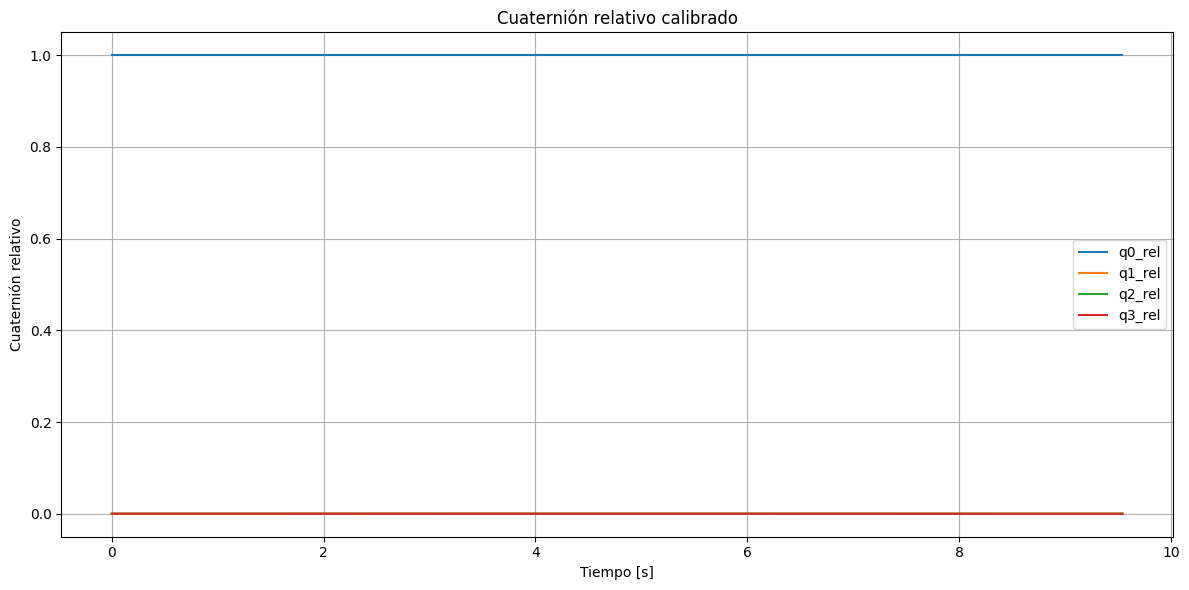

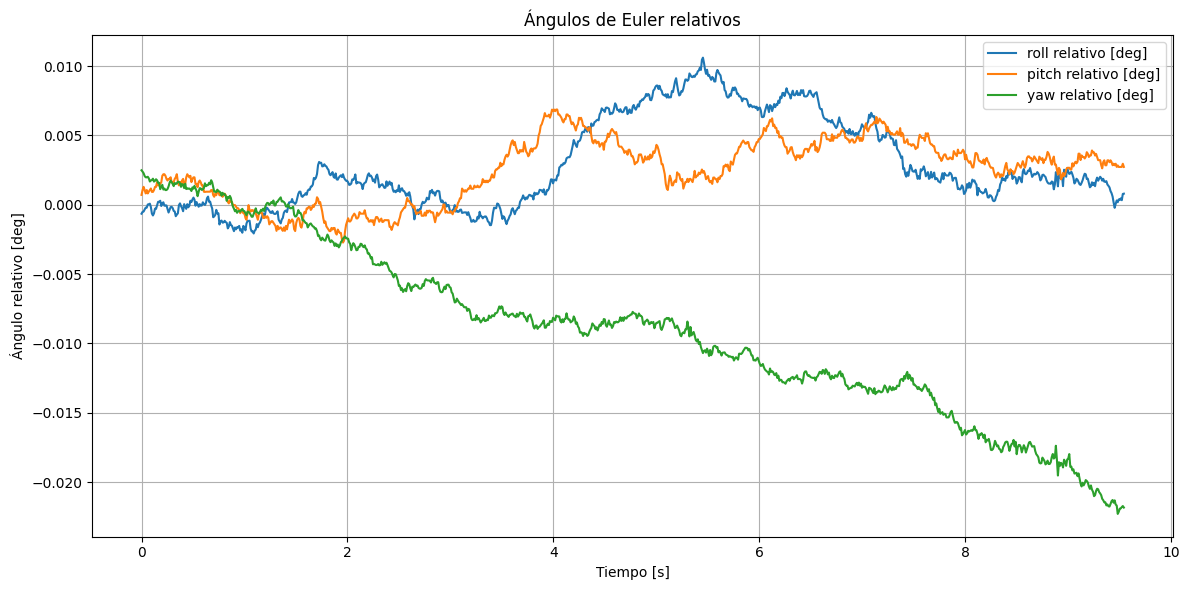

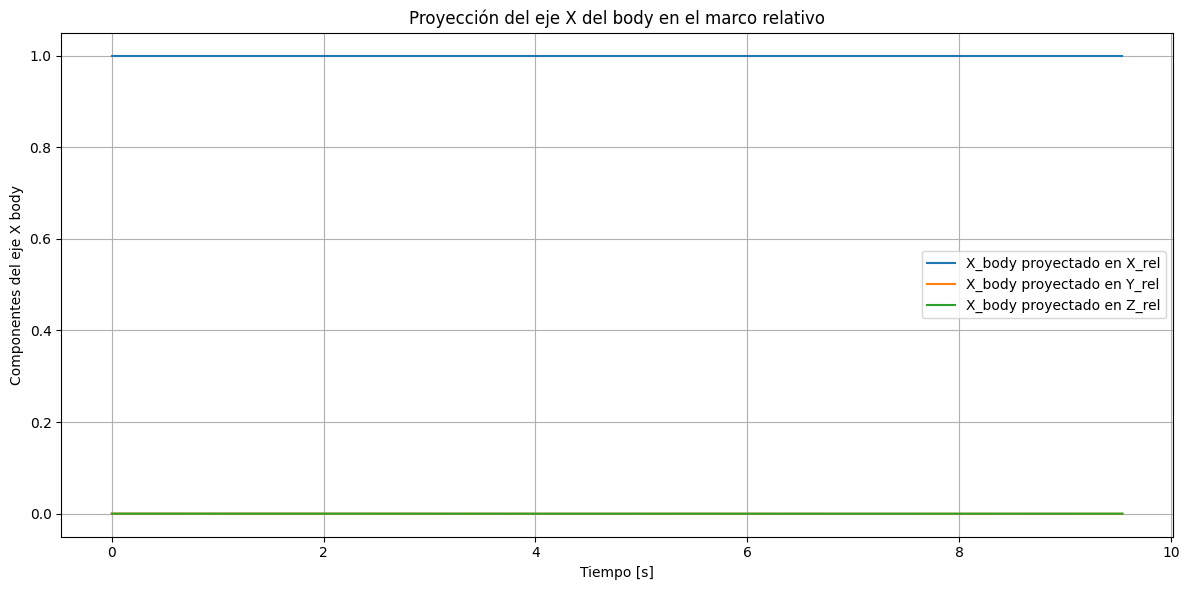

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R


# ============================================================
# 1. Leer CSV de SensorConnect desde DATA_START
# ============================================================

def read_quaternion_sensorconnect_csv(filepath):
    """
    Lee un CSV exportado por SensorConnect que contiene DATA_START.

    Formato esperado:
        DATA_START
        Time,
        inertial-xxxx:estOrientQuaternion[0-0],
        inertial-xxxx:estOrientQuaternion[0-1],
        inertial-xxxx:estOrientQuaternion[0-2],
        inertial-xxxx:estOrientQuaternion[0-3],
        inertial-xxxx:estOrientQuaternion:valid

    Retorna:
        DataFrame con columnas:
            Time, q0, q1, q2, q3, qValid, t
    """

    # Buscar fila donde aparece DATA_START
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    data_start_idx = None

    for i, line in enumerate(lines):
        if line.strip() == "DATA_START":
            data_start_idx = i
            break

    if data_start_idx is None:
        raise ValueError("No se encontró DATA_START en el archivo.")

    # La cabecera real está justo después de DATA_START
    header_idx = data_start_idx + 1

    df = pd.read_csv(filepath, skiprows=header_idx)

    # Limpiar nombres de columnas
    df.columns = df.columns.str.strip()

    # Detectar columnas de cuaternión
    q_cols_raw = [
        col for col in df.columns
        if "estOrientQuaternion[0-" in col
    ]

    q_cols_raw = sorted(q_cols_raw)

    if len(q_cols_raw) != 4:
        raise ValueError(
            f"No se encontraron 4 columnas de cuaternión. Encontradas: {q_cols_raw}"
        )

    # Detectar columna valid
    valid_cols = [
        col for col in df.columns
        if "estOrientQuaternion:valid" in col
    ]

    if len(valid_cols) == 0:
        raise ValueError("No se encontró columna estOrientQuaternion:valid.")

    valid_col = valid_cols[0]

    # Renombrar
    rename_map = {
        q_cols_raw[0]: "q0",
        q_cols_raw[1]: "q1",
        q_cols_raw[2]: "q2",
        q_cols_raw[3]: "q3",
        valid_col: "qValid",
    }

    df = df.rename(columns=rename_map)

    # Convertir a numérico
    cols_needed = ["Time", "q0", "q1", "q2", "q3", "qValid"]

    for col in cols_needed:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Eliminar filas inválidas o incompletas
    df = df.dropna(subset=cols_needed).copy()

    # Filtrar solo cuaterniones válidos
    df = df[df["qValid"] == 1].copy()

    # Eliminar cuaterniones cero
    q_norm = np.linalg.norm(df[["q0", "q1", "q2", "q3"]].to_numpy(), axis=1)
    df = df[q_norm > 1e-9].copy()

    # Normalizar cuaterniones
    q = df[["q0", "q1", "q2", "q3"]].to_numpy(dtype=float)
    q = q / np.linalg.norm(q, axis=1, keepdims=True)

    df["q0"] = q[:, 0]
    df["q1"] = q[:, 1]
    df["q2"] = q[:, 2]
    df["q3"] = q[:, 3]

    # Tiempo relativo en segundos
    df = df.sort_values("Time").reset_index(drop=True)
    df["t"] = (df["Time"] - df["Time"].iloc[0]) / 1e9

    return df


# ============================================================
# 2. Conversión de formato de cuaternión
# ============================================================

def wxyz_to_xyzw(q_wxyz):
    """
    Convierte cuaternión [w, x, y, z] a [x, y, z, w],
    que es el formato usado por scipy.spatial.transform.Rotation.
    """
    q_wxyz = np.asarray(q_wxyz, dtype=float)

    return np.array([
        q_wxyz[1],
        q_wxyz[2],
        q_wxyz[3],
        q_wxyz[0],
    ])


def xyzw_to_wxyz(q_xyzw):
    """
    Convierte cuaternión [x, y, z, w] a [w, x, y, z].
    """
    q_xyzw = np.asarray(q_xyzw, dtype=float)

    return np.array([
        q_xyzw[3],
        q_xyzw[0],
        q_xyzw[1],
        q_xyzw[2],
    ])


# ============================================================
# 3. Obtener cuaternión de referencia inicial
# ============================================================

def get_initial_reference_quaternion(df, method="first", initial_time_window=2.0):
    """
    Obtiene el cuaternión inicial de referencia.

    method:
        "first":
            usa el primer cuaternión válido.

        "mean":
            promedia los cuaterniones durante los primeros
            initial_time_window segundos.

    Retorna:
        scipy Rotation R_ref
    """

    if method == "first":
        q_ref_wxyz = df[["q0", "q1", "q2", "q3"]].iloc[0].to_numpy(dtype=float)
        q_ref_wxyz = q_ref_wxyz / np.linalg.norm(q_ref_wxyz)

        R_ref = R.from_quat(wxyz_to_xyzw(q_ref_wxyz))
        return R_ref

    elif method == "mean":
        df_init = df[df["t"] <= initial_time_window].copy()

        if len(df_init) == 0:
            raise ValueError("No hay muestras dentro de la ventana inicial.")

        q_init_wxyz = df_init[["q0", "q1", "q2", "q3"]].to_numpy(dtype=float)

        # Normalizar
        q_init_wxyz = q_init_wxyz / np.linalg.norm(q_init_wxyz, axis=1, keepdims=True)

        # Promedio simple con corrección de signo.
        # Los cuaterniones q y -q representan la misma orientación.
        # Se alinean todos al signo del primero.
        q0 = q_init_wxyz[0]

        for k in range(len(q_init_wxyz)):
            if np.dot(q0, q_init_wxyz[k]) < 0:
                q_init_wxyz[k] *= -1.0

        q_ref_wxyz = np.mean(q_init_wxyz, axis=0)
        q_ref_wxyz = q_ref_wxyz / np.linalg.norm(q_ref_wxyz)

        R_ref = R.from_quat(wxyz_to_xyzw(q_ref_wxyz))
        return R_ref

    else:
        raise ValueError("method debe ser 'first' o 'mean'.")


# ============================================================
# 4. Calibrar orientación absoluta a orientación relativa
# ============================================================

def calibrate_quaternion_to_relative(
    df,
    reference_method="first",
    initial_time_window=2.0,
    euler_sequence="xyz"
):
    """
    Calcula cuaterniones relativos:

        q_rel(t) = q_ref^{-1} ⊗ q(t)

    Hace que la orientación inicial sea aproximadamente:

        [1, 0, 0, 0]

    Entrada:
        df con columnas q0, q1, q2, q3 en formato [w,x,y,z].

    Salida:
        df con columnas:
            q0_rel, q1_rel, q2_rel, q3_rel
            roll_rel_deg, pitch_rel_deg, yaw_rel_deg
    """

    df = df.copy()

    R_ref = get_initial_reference_quaternion(
        df,
        method=reference_method,
        initial_time_window=initial_time_window
    )

    q_rel_list = []
    euler_rel_list = []

    for _, row in df.iterrows():
        q_wxyz = row[["q0", "q1", "q2", "q3"]].to_numpy(dtype=float)
        q_wxyz = q_wxyz / np.linalg.norm(q_wxyz)

        R_current = R.from_quat(wxyz_to_xyzw(q_wxyz))

        # Calibración relativa
        R_rel = R_ref.inv() * R_current

        q_rel_xyzw = R_rel.as_quat()
        q_rel_wxyz = xyzw_to_wxyz(q_rel_xyzw)

        q_rel_list.append(q_rel_wxyz)

        euler_rel_deg = R_rel.as_euler(euler_sequence, degrees=True)
        euler_rel_list.append(euler_rel_deg)

    q_rel = np.array(q_rel_list)
    euler_rel = np.array(euler_rel_list)

    df["q0_rel"] = q_rel[:, 0]
    df["q1_rel"] = q_rel[:, 1]
    df["q2_rel"] = q_rel[:, 2]
    df["q3_rel"] = q_rel[:, 3]

    df["roll_rel_deg"] = euler_rel[:, 0]
    df["pitch_rel_deg"] = euler_rel[:, 1]
    df["yaw_rel_deg"] = euler_rel[:, 2]

    return df


# ============================================================
# 5. Prueba con vectores unitarios del body
# ============================================================

def test_body_axes_after_relative_calibration(df):
    """
    Rota los ejes unitarios del body usando la orientación relativa.

    Permite ver cómo queda el eje X, Y y Z del IMU/vehículo
    en el marco relativo.

    Devuelve:
        df con columnas:
            x_axis_nav_x, x_axis_nav_y, x_axis_nav_z
            y_axis_nav_x, ...
            z_axis_nav_x, ...
    """

    df = df.copy()

    x_body = np.array([1.0, 0.0, 0.0])
    y_body = np.array([0.0, 1.0, 0.0])
    z_body = np.array([0.0, 0.0, 1.0])

    x_nav_list = []
    y_nav_list = []
    z_nav_list = []

    for _, row in df.iterrows():
        q_rel_wxyz = row[["q0_rel", "q1_rel", "q2_rel", "q3_rel"]].to_numpy(dtype=float)
        q_rel_wxyz = q_rel_wxyz / np.linalg.norm(q_rel_wxyz)

        R_rel = R.from_quat(wxyz_to_xyzw(q_rel_wxyz))

        x_nav = R_rel.apply(x_body)
        y_nav = R_rel.apply(y_body)
        z_nav = R_rel.apply(z_body)

        x_nav_list.append(x_nav)
        y_nav_list.append(y_nav)
        z_nav_list.append(z_nav)

    x_nav_arr = np.array(x_nav_list)
    y_nav_arr = np.array(y_nav_list)
    z_nav_arr = np.array(z_nav_list)

    df["x_axis_nav_x"] = x_nav_arr[:, 0]
    df["x_axis_nav_y"] = x_nav_arr[:, 1]
    df["x_axis_nav_z"] = x_nav_arr[:, 2]

    df["y_axis_nav_x"] = y_nav_arr[:, 0]
    df["y_axis_nav_y"] = y_nav_arr[:, 1]
    df["y_axis_nav_z"] = y_nav_arr[:, 2]

    df["z_axis_nav_x"] = z_nav_arr[:, 0]
    df["z_axis_nav_y"] = z_nav_arr[:, 1]
    df["z_axis_nav_z"] = z_nav_arr[:, 2]

    return df


# ============================================================
# 6. Plots
# ============================================================

def plot_quaternion_relative(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df["t"], df["q0_rel"], label="q0_rel")
    plt.plot(df["t"], df["q1_rel"], label="q1_rel")
    plt.plot(df["t"], df["q2_rel"], label="q2_rel")
    plt.plot(df["t"], df["q3_rel"], label="q3_rel")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Cuaternión relativo")
    plt.title("Cuaternión relativo calibrado")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_euler_relative(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df["t"], df["roll_rel_deg"], label="roll relativo [deg]")
    plt.plot(df["t"], df["pitch_rel_deg"], label="pitch relativo [deg]")
    plt.plot(df["t"], df["yaw_rel_deg"], label="yaw relativo [deg]")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Ángulo relativo [deg]")
    plt.title("Ángulos de Euler relativos")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_body_x_axis_projection(df):
    plt.figure(figsize=(12, 6))
    plt.plot(df["t"], df["x_axis_nav_x"], label="X_body proyectado en X_rel")
    plt.plot(df["t"], df["x_axis_nav_y"], label="X_body proyectado en Y_rel")
    plt.plot(df["t"], df["x_axis_nav_z"], label="X_body proyectado en Z_rel")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Componentes del eje X body")
    plt.title("Proyección del eje X del body en el marco relativo")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Main
# ============================================================

if __name__ == "__main__":

    filepath = r"calibracion_orientacion\cuat_3.csv"

    df = read_quaternion_sensorconnect_csv(filepath)

    print("Primeras filas leídas:")
    print(df.head())

    print("\nCuaternión inicial original [w,x,y,z]:")
    print(df[["q0", "q1", "q2", "q3"]].iloc[0].to_numpy())

    # Calibrar orientación inicial a identidad
    df_rel = calibrate_quaternion_to_relative(
        df,
        reference_method="mean",       # "first" o "mean"
        initial_time_window=2.0,
        euler_sequence="xyz"
    )

    print("\nPrimer cuaternión relativo [w,x,y,z]:")
    print(df_rel[["q0_rel", "q1_rel", "q2_rel", "q3_rel"]].iloc[0].to_numpy())

    print("\nPrimeros ángulos relativos [deg]:")
    print(df_rel[["roll_rel_deg", "pitch_rel_deg", "yaw_rel_deg"]].head())

    # Probar ejes body luego de la calibración
    df_rel = test_body_axes_after_relative_calibration(df_rel)

    print("\nPrimer eje X body proyectado al marco relativo:")
    print(df_rel[["x_axis_nav_x", "x_axis_nav_y", "x_axis_nav_z"]].iloc[0].to_numpy())

    # Guardar resultado
    output_file = "quaternions_relative_calibrated.csv"
    df_rel.to_csv(output_file, index=False)

    print(f"\nArchivo guardado: {output_file}")

    # Graficar resultados
    plot_quaternion_relative(df_rel)
    plot_euler_relative(df_rel)
    plot_body_x_axis_projection(df_rel)